In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [122]:
features_df = pd.read_csv("best_features.csv", sep=';')
errors_df = pd.read_csv("results.csv", sep=';')

In [123]:
features_df.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10
0,"'MID', 3, 1, -3","'MID', 3, 3, 2","'FAR', -1, -1, -2","'FAR', -2, -3, -1","'FAR', 2, -2, 0","'FAR', -2, 3, -3","'MID', 3, 1, -1","'MID', 3, -3, 1","'NEAR_dip-angle_', -2, 1, 3","'FAR', -1, -3, 0"
1,"'FAR', -2, 3, 1","'FAR', 0, 0, -2","'FAR', -3, 1, 2","'NEAR_dip-curvature_', 3, 0, -3","'NEAR_dip-angle_', -3, -3, 3","'MID', -3, 2, 1","'NEAR_curvedness_', 2, 2, 3","'NEAR_curvedness_', 1, 2, 3","'NEAR_curvedness_', 2, -1, -1","'NEAR_curvedness_', -3, 0, 3"
2,"'MID', 0, 3, 3","'MID', 2, -1, -3","'MID', -2, 1, 2","'NEAR_envelope_', -1, -3, -2","'NEAR_curvedness_', 3, 1, -2","'NEAR_envelope_', 3, 2, 2","'NEAR_dip-curvature_', -1, 3, 0","'NEAR_contour-curvature_', -2, 3, 0","'NEAR_dip-curvature_', 1, 0, -2","'NEAR_gaussian-curvature_', 1, 2, -3"
3,"'MID', 0, 1, 3","'FAR', 0, 0, -2","'NEAR_dip-angle_', 3, -3, -3","'NEAR_contour-curvature_', -3, -3, -3","'FAR', -3, -2, 1","'NEAR_contour-curvature_', -3, 0, 3","'NEAR_curvedness_', 2, 3, 3","'NEAR_azimuth_', 3, 0, -2",dummy,dummy
4,"'MID', -1, 2, 3","'MID', 1, 0, -3","'NEAR_dip-angle_', 3, 1, 2","'NEAR_contour-curvature_', -1, -3, -2","'NEAR_curvedness_', 1, 2, 3","'NEAR_contour-curvature_', -3, -3, -3","'NEAR_gaussian-curvature_', -3, -2, 3","'NEAR_azimuth_', 2, 3, 3","'NEAR_curvedness_', 1, -3, -2","'NEAR_azimuth_', -3, 3, 2"


In [124]:
errors_df.head()

,error1,error2,error3,error4,error5,error6,error7,error8,error9,error10
0,0.021153,0.019349,0.019043,0.018301,0.018108,0.017769,0.017506,0.017174,0.017225,0.017071
1,0.034267,0.032454,0.031708,0.030670,0.029974,0.029264,0.028922,0.028897,0.028782,0.028541
2,0.039562,0.038071,0.036874,0.036397,0.036278,0.035896,0.035517,0.035254,0.034877,0.034612
3,0.041415,0.039681,0.039387,0.039065,0.038784,0.038532,0.038808,0.038796,NaN,NaN
4,0.042600,0.040328,0.039950,0.039631,0.039320,0.039103,0.039092,0.039099,0.039057,0.039051


In [125]:
max_error = errors_df.max().max()
min_error = errors_df.min().min()

In [126]:
def get_preffix(feat_name):
    splitted = feat_name.split("'")
    if len(splitted) > 1:
        return splitted[1]
    else:
        return splitted[0]
    
def get_feat_preffix_series(feature_series):
    serie = feature_series.apply(get_preffix)
    return serie

In [127]:
treated_features = features_df.apply(get_feat_preffix_series)

In [128]:
treated_features.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10
0,MID,MID,FAR,FAR,FAR,FAR,MID,MID,NEAR_dip-angle_,FAR
1,FAR,FAR,FAR,NEAR_dip-curvature_,NEAR_dip-angle_,MID,NEAR_curvedness_,NEAR_curvedness_,NEAR_curvedness_,NEAR_curvedness_
2,MID,MID,MID,NEAR_envelope_,NEAR_curvedness_,NEAR_envelope_,NEAR_dip-curvature_,NEAR_contour-curvature_,NEAR_dip-curvature_,NEAR_gaussian-curvature_
3,MID,FAR,NEAR_dip-angle_,NEAR_contour-curvature_,FAR,NEAR_contour-curvature_,NEAR_curvedness_,NEAR_azimuth_,dummy,dummy
4,MID,MID,NEAR_dip-angle_,NEAR_contour-curvature_,NEAR_curvedness_,NEAR_contour-curvature_,NEAR_gaussian-curvature_,NEAR_azimuth_,NEAR_curvedness_,NEAR_azimuth_


In [129]:
#Dict of list of two lists
feature_points = dict()

for row_idx, row in treated_features.iterrows():
    col_idx = 0
    for feature in row:
        feat_points = feature_points.setdefault(feature, [[],[]])
        feat_points[0].append(row_idx+1)
        feat_points[1].append(col_idx+1)
        col_idx +=1

In [130]:
for key, value in feature_points.items():
    print(f"{key}: \n{value[0]}, \n{value[1]}\n")

MID: 
[1, 1, 1, 1, 2, 3, 3, 3, 4, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 12, 12, 12, 12, 13, 13, 14, 14, 14, 15, 15, 16, 16, 16, 17, 17, 17, 17, 18, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 21, 21, 21, 22, 22, 23, 23, 24, 24, 24, 25, 25, 26, 26, 26, 27, 27, 28, 28, 28, 29, 29], 
[1, 2, 7, 8, 6, 1, 2, 3, 1, 1, 2, 1, 2, 1, 2, 1, 2, 3, 1, 2, 4, 1, 2, 5, 1, 3, 1, 2, 4, 7, 1, 2, 1, 2, 5, 1, 2, 1, 2, 4, 1, 2, 4, 5, 1, 2, 6, 1, 2, 4, 5, 1, 2, 4, 7, 1, 2, 5, 1, 2, 1, 2, 1, 2, 3, 1, 2, 1, 2, 7, 1, 2, 1, 2, 4, 1, 2]

FAR: 
[1, 1, 1, 1, 1, 2, 2, 2, 4, 4, 7, 7, 7, 8, 8, 9, 10, 11, 11, 12, 13, 13, 13, 14, 14, 15, 15, 16, 18, 18, 19, 20, 20, 21, 22, 22, 23, 23, 23, 25, 25, 25, 26, 27, 27, 27, 28, 29, 29], 
[3, 4, 5, 6, 10, 1, 2, 3, 2, 5, 3, 4, 6, 4, 5, 3, 3, 2, 4, 3, 3, 5, 6, 3, 7, 3, 6, 3, 3, 4, 3, 3, 6, 4, 3, 5, 3, 4, 6, 3, 5, 6, 3, 3, 4, 5, 3, 3, 5]

NEAR_dip-angle_: 
[1, 2, 4, 5, 21, 21], 
[9, 5, 3, 3, 6, 8]

NEAR_dip-curvature_: 
[2, 3, 3, 7, 8, 10, 11, 15, 16, 16, 17, 20, 23, 2

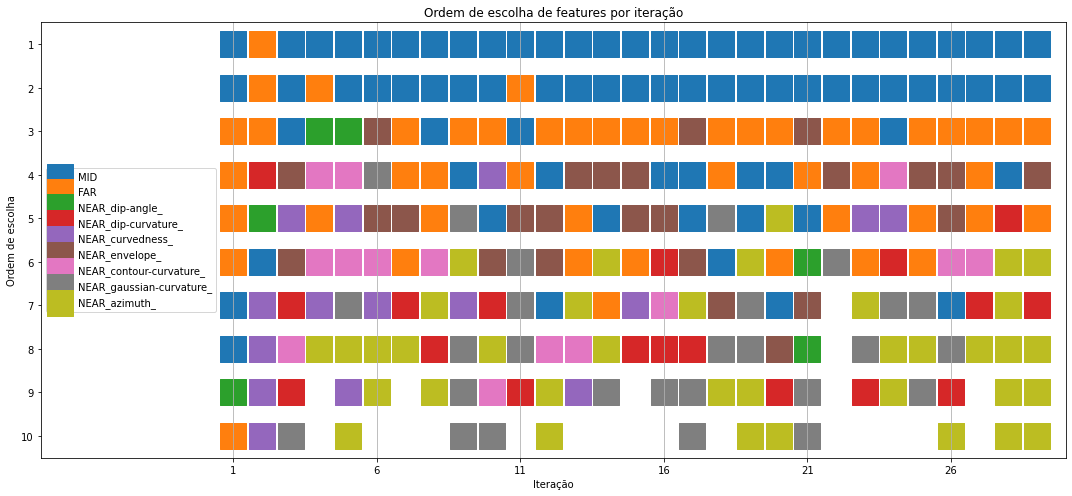

In [141]:
plt.figure(figsize=(15, 7))

for feat_name, (it_values, rank_values) in feature_points.items():
    if feat_name != 'dummy':
        num_points = len(it_values)
        plt.scatter(it_values, rank_values, marker='s', s=650, label=feat_name)##, mfc="w")

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")
plt.legend(loc='center left')
plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
plt.yticks([rank for rank in range(1, 11)])
plt.xticks([it for it in range(1, 30, 5)])
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
# plt.show()
plt.savefig("features_per_it.jpg")

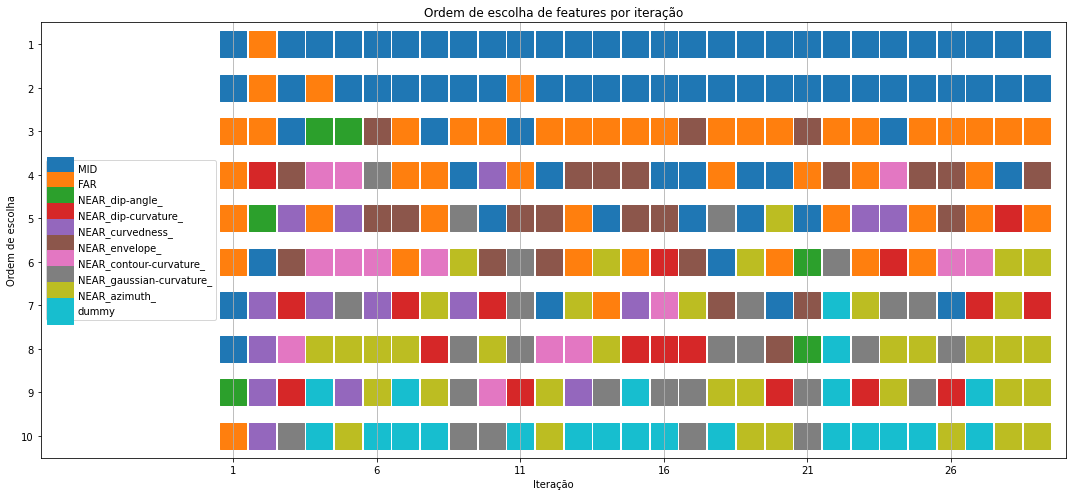

In [142]:
plt.figure(figsize=(15, 7))

for feat_name, (it_values, rank_values) in feature_points.items():
    num_points = len(it_values)
    plt.scatter(it_values, rank_values, marker='s', s=650, label=feat_name)##, mfc="w")

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")
plt.legend(loc='center left')
plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
plt.yticks([rank for rank in range(1, 11)])
plt.xticks([it for it in range(1, 30, 5)])
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
# plt.show()
plt.savefig("features_per_it_dummy.jpg")

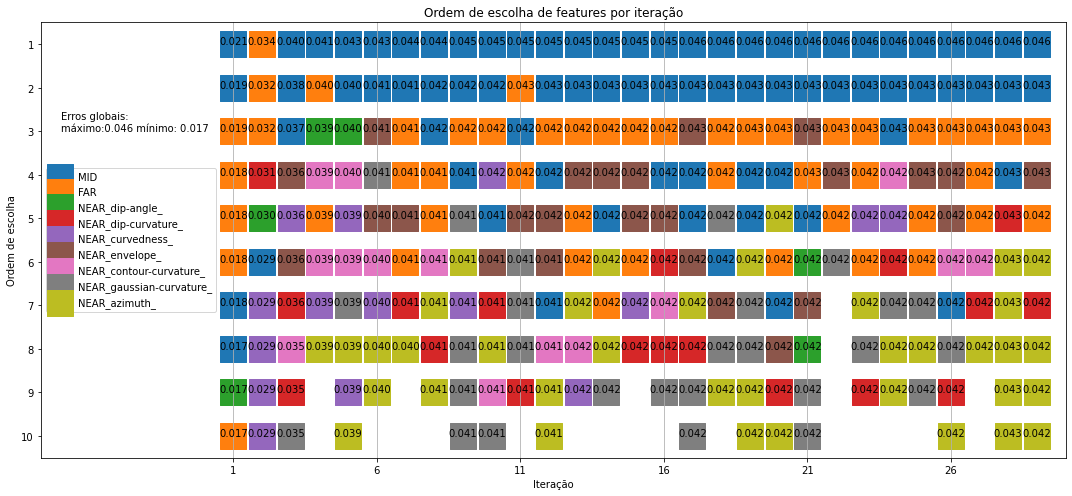

In [139]:
plt.figure(figsize=(15, 7))

for feat_name, (it_values, rank_values) in feature_points.items():
    if feat_name != "dummy":
        num_points = len(it_values)
        plt.scatter(it_values, rank_values, marker='s', s=650, label=feat_name)

    
for row_idx, row in errors_df.iterrows():
    col_idx = 0
    for error in row:
        if not math.isnan(error):
            plt.text(row_idx+0.5, col_idx+1, "%.3f" %error)
        col_idx +=1

#Printa info
exp= "Erros globais:\nmáximo:%.3f mínimo: %.3f" % (max_error, min_error)
plt.text(start_x-1, 3, exp)

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")
plt.legend(loc='center left')
plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
plt.yticks([rank for rank in range(1, 11)])
plt.xticks([it for it in range(1, 30, 5)])
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
#plt.show()
plt.savefig("errors_per_it_boxes.jpg")

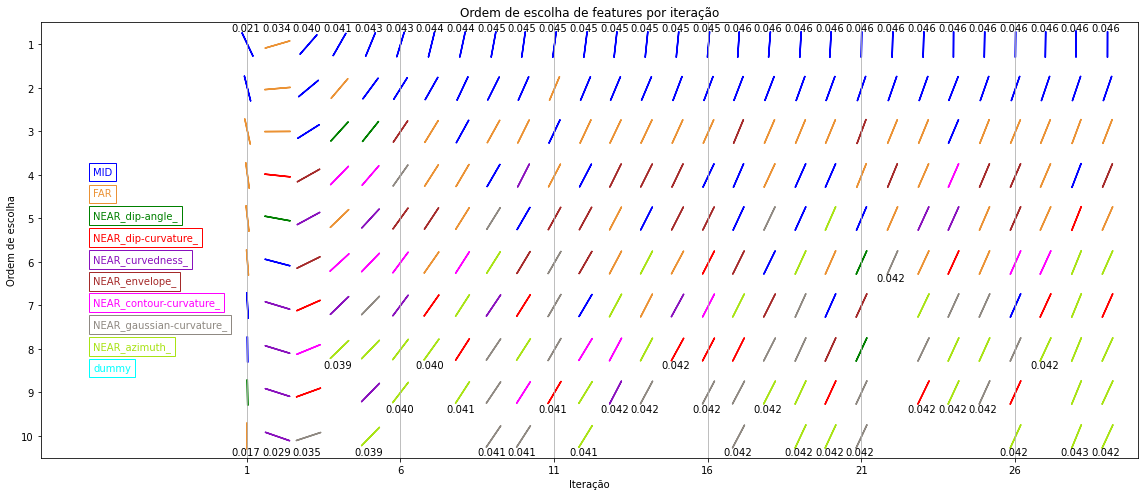

In [89]:
plt.figure(figsize=(16, 7))

max_scaled = max_error - min_error
min_scaled = 0

min_angle = 0
max_angle = 180

feats_colors = {
    'MID': 'blue',
    'FAR':'#eb9234',
    'NEAR_dip-angle_':'green',
    'NEAR_dip-curvature_':'red',
    'NEAR_curvedness_':'#8911bd',
    'NEAR_envelope_':'brown',
    'NEAR_contour-curvature_':'magenta',
    'NEAR_gaussian-curvature_':'#8f8982',
    'NEAR_azimuth_':'#a8e314',
    'dummy':'cyan'
}

for feat_name, (it_values, rank_values) in feature_points.items():
    num_points = len(it_values)
    
    if feat_name != "dummy":
        for (x, y) in zip(it_values, rank_values):
            curr_error_scaled = errors_df.iloc[x-1][y-1] - min_error
            resulting_angle = (curr_error_scaled/max_scaled)*max_angle
            
            plt.scatter(x, y, marker=(2, 2, resulting_angle), s=650, c=feats_colors[feat_name])

    
for row_idx, row in errors_df.iterrows():
    first_error = row[0]
    
    last_num_error = 0
    last_num_error_idx = 0
    last_error = 0
    for error in row:
        if not math.isnan(error):
            last_error = error
        else:
            break
        last_num_error_idx +=1
    
    plt.text(row_idx+0.5, 0.7, "%.3f" % first_error)
    plt.text(row_idx+0.5, last_num_error_idx+0.45, "%.3f" % last_error)
    
#Print legend:
start_x = -4
start_y = 4

for feat_idx, (feat, color) in enumerate(list(feats_colors.items())):
    plt.text(start_x, start_y+(feat_idx*0.5), feat, color=color, bbox=dict(facecolor='none', edgecolor=color))

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")

plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
plt.yticks([rank for rank in range(1, 11)])
plt.xticks([it for it in range(1, 30, 5)])
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
plt.show()
# plt.savefig("features_per_it.jpg")

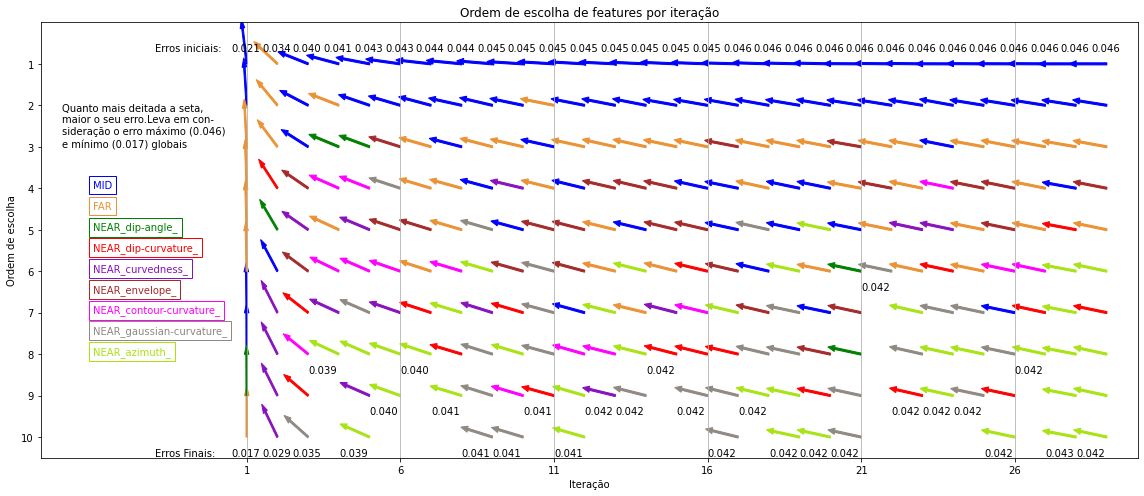

In [140]:
import math

plt.figure(figsize=(16, 7))

max_error = errors_df.max().max()
min_error = errors_df.min().min()

max_scaled = max_error - min_error
min_scaled = 0

feats_colors = {
    'MID': 'blue',
    'FAR':'#eb9234',
    'NEAR_dip-angle_':'green',
    'NEAR_dip-curvature_':'red',
    'NEAR_curvedness_':'#8911bd',
    'NEAR_envelope_':'brown',
    'NEAR_contour-curvature_':'magenta',
    'NEAR_gaussian-curvature_':'#8f8982',
    'NEAR_azimuth_':'#a8e314',
    #'dummy':'cyan'
}

#Printa as setas
for feat_name, (it_values, rank_values) in feature_points.items():
    num_points = len(it_values)
    angles = [180]*num_points
    
    if feat_name != "dummy":
        for (x, y) in zip(it_values, rank_values):
            curr_error_scaled = errors_df.iloc[x-1][y-1] - min_error
            resulting_y_target = (curr_error_scaled/max_scaled)-1
            
            resulting_x_target =  -1*curr_error_scaled/max_scaled
            
            plt.arrow(x, y, resulting_x_target, resulting_y_target, width=0.05, color=feats_colors[feat_name])


#Printa os erros iniciais e finais de cada iteração
for row_idx, row in errors_df.iterrows():
    first_error = row[0]
    
    last_num_error = 0
    last_num_error_idx = 0
    last_error = 0
    for error in row:
        if not math.isnan(error):
            last_error = error
        else:
            break
        last_num_error_idx +=1
    
    x_alt = 0.5
    plt.text(row_idx+x_alt, 0.7, "%.3f" % first_error)
    if row_idx > 2:
        x_alt = 0
    plt.text(row_idx+x_alt, last_num_error_idx+0.45, "%.3f" % last_error)

#Print legend:
start_x = -4
start_y = 4

for feat_idx, (feat, color) in enumerate(list(feats_colors.items())):
    plt.text(start_x, start_y+(feat_idx*0.5), feat, color=color, bbox=dict(facecolor='none', edgecolor=color))

    
#Print explicação
exp = f"Quanto mais deitada a seta,\nmaior o seu erro."
exp+= "Leva em con-\nsideração o erro máximo (%.3f)\ne mínimo (%.3f) globais" % (max_error, min_error)
plt.text(start_x-1, 3, exp)

#Print headers for errors
plt.text(-2, 0.7, "Erros iniciais:")
plt.text(-2, 10+0.45, "Erros Finais:")

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")

plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.0, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
plt.yticks([rank for rank in range(1, 11)])
plt.xticks([it for it in range(1, 30, 5)])

plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
# plt.show()
plt.savefig("errors_per_it_arrow.jpg")

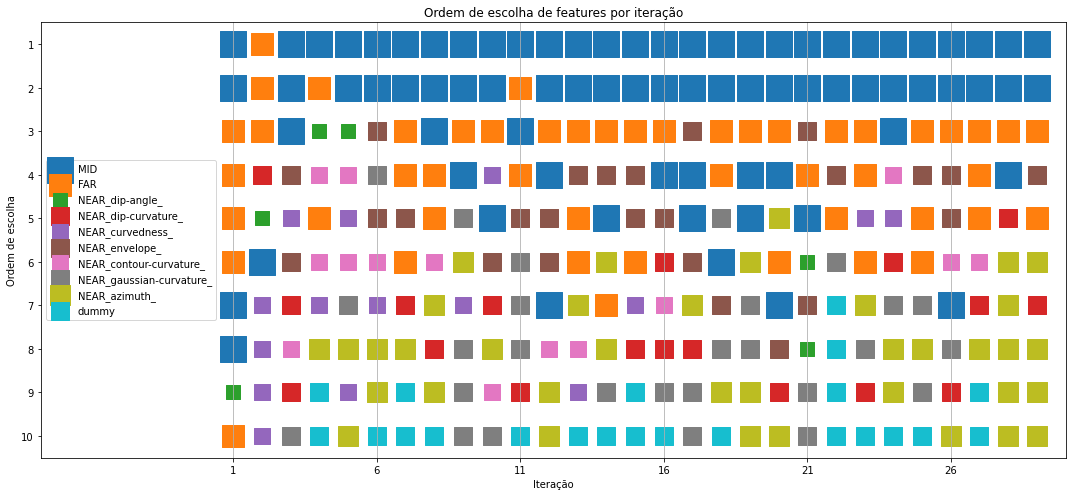

In [77]:
max_points = 0
for feat_name, (it_values, rank_values) in feature_points.items():
    curr_num_points = len(it_values) 
    if curr_num_points > max_points:
        max_points = curr_num_points

plt.figure(figsize=(15, 7))
for feat_name, (it_values, rank_values) in feature_points.items():
    num_points = len(it_values)
    plt.scatter(it_values, rank_values, marker='s', s=650-(6*(max_points-num_points)), label=feat_name)##, mfc="w")

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")
plt.legend(loc='center left')
plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
plt.yticks([rank for rank in range(1, 11)])
plt.xticks([it for it in range(1, 30, 5)])
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
plt.show()

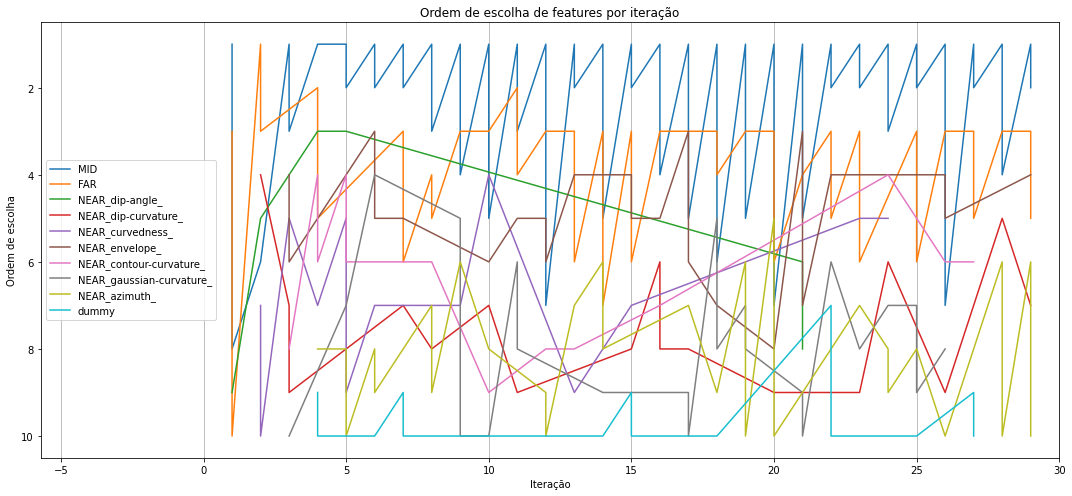

In [40]:
plt.figure(figsize=(15, 7))
for feat_name, (it_values, rank_values) in feature_points.items():
    plt.plot(it_values, rank_values, label=feat_name)##, mfc="w")

# Define Labels
plt.xlabel('Iteração')
plt.ylabel('Ordem de escolha')

plt.grid(axis="x")
plt.legend(loc='center left')
plt.axis([None, None, -1, 1])

n_top_ranked = 10
plt.ylim(0.5, 0.5+ n_top_ranked)
plt.xlim(-5.7, 30)
#voltar
plt.gca().invert_yaxis()
plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
plt.show()

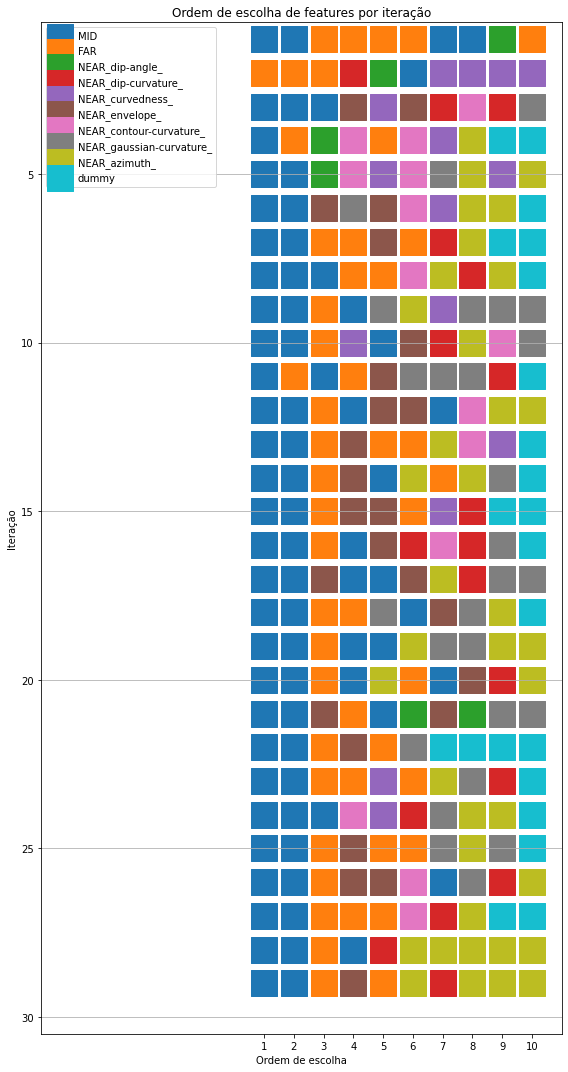

In [69]:
plt.figure(figsize=(8, 15))
for feat_name, (it_values, rank_values) in feature_points.items():
    plt.scatter(rank_values, it_values, s=650, marker='s', label=feat_name)#, mfc="w")

# Define Labels
plt.ylabel('Iteração')
plt.xlabel('Ordem de escolha')

plt.grid(axis="y")
plt.legend(loc='upper left')
plt.axis([None, None, -1, 1])

n_top_ranked = 30
plt.ylim(0.5+ n_top_ranked, 0.5 )
plt.xlim(-6.5, 11)

plt.xticks([rank for rank in range(1, 11)])

plt.title("Ordem de escolha de features por iteração")
plt.tight_layout()
plt.show()